In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Car_sales.csv')

In [4]:
df

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,NaN,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,Volvo,S70,15.245,NaN,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,Volvo,V70,17.531,NaN,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,Volvo,C70,3.493,NaN,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


In [5]:
df=df[['Manufacturer', 'Sales_in_thousands', 'Vehicle_type',
       'Price_in_thousands', 'Engine_size', 'Horsepower', 'Fuel_capacity']]

In [6]:
df

,Manufacturer,Sales_in_thousands,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
0,Acura,16.919,Passenger,21.50,1.8,140.0,13.2
1,Acura,39.384,Passenger,28.40,3.2,225.0,17.2
2,Acura,14.114,Passenger,NaN,3.2,225.0,17.2
3,Acura,8.588,Passenger,42.00,3.5,210.0,18.0
4,Audi,20.397,Passenger,23.99,1.8,150.0,16.4
...,...,...,...,...,...,...,...
152,Volvo,3.545,Passenger,24.40,1.9,160.0,15.8
153,Volvo,15.245,Passenger,27.50,2.4,168.0,17.9
154,Volvo,17.531,Passenger,28.80,2.4,168.0,17.9
155,Volvo,3.493,Passenger,45.50,2.3,236.0,18.5


In [7]:
df.nunique()

Manufacturer           30
Sales_in_thousands    157
Vehicle_type            2
Price_in_thousands    152
Engine_size            31
Horsepower             66
Fuel_capacity          55
dtype: int64

In [8]:
df.agg('sum')

Manufacturer          AcuraAcuraAcuraAcuraAudiAudiAudiBMWBMWBMWBuick...
Sales_in_thousands                                             8320.698
Vehicle_type          PassengerPassengerPassengerPassengerPassengerP...
Price_in_thousands                                             4245.567
Engine_size                                                       477.5
Horsepower                                                      29008.0
Fuel_capacity                                                    2800.5
dtype: object

In [9]:
df.agg('mean',numeric_only=True)

Sales_in_thousands     52.998076
Price_in_thousands     27.390755
Engine_size             3.060897
Horsepower            185.948718
Fuel_capacity          17.951923
dtype: float64

In [10]:
# here multiple aggregation methords are implemented by giving them in [''] form
df.select_dtypes(include='number').agg(['mean', 'count'])

,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
mean,52.998076,27.390755,3.060897,185.948718,17.951923
count,157.000000,155.000000,156.000000,156.000000,156.000000


In [11]:
# here we apply diffrent agg methords to diffrent columns for result it is declared as {"Key": ['val1', 'val2']}
df.agg({'Sales_in_thousands': ['sum', 'mean'],
        'Price_in_thousands': ['sum', 'max']
       })

,Sales_in_thousands,Price_in_thousands
sum,8320.698000,4245.567
mean,52.998076,NaN
max,NaN,85.500


In [12]:
# operation done on two cols and resultant is print so sale + price of each row is given:
df[['Sales_in_thousands', 'Price_in_thousands']].agg('sum', axis=1)

0      38.419
1      67.784
2      14.114
3      50.588
4      44.387
        ...  
152    27.945
153    42.745
154    46.331
155    48.993
156    54.969
Length: 157, dtype: float64

In [13]:
df.agg(x=('Sales_in_thousands', 'sum'), y=('Price_in_thousands', 'sum'))

,Sales_in_thousands,Price_in_thousands
x,8320.698,NaN
y,NaN,4245.567


### Split apply combine strategy for grouping

In [14]:
# Splitting through filtering
car=df['Vehicle_type']=='Car'
passenger=df['Vehicle_type']=='Passenger'

In [15]:
# apply by ging specific values for diffrent filters
car_a=df[car]['Sales_in_thousands'].agg('mean')
passenger_a=df[passenger]['Sales_in_thousands'].agg('mean')

In [16]:
# combine the result and form a new df
pd.DataFrame({'Vehicle_type': ['Car', 'Passanger'],
              'Sales_in_thousands': [car_a, passenger_a]
             })

,Vehicle_type,Sales_in_thousands
0,Car,80.622293
1,Passanger,43.234345


### groupby() will be used to do the above done task in more siple way

In [17]:
df.groupby('Vehicle_type').agg('mean', numeric_only=True)

,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
Vehicle_type,,,,,
Car,80.622293,26.319975,3.520000,186.400000,21.895000
Passenger,43.234345,27.763200,2.902586,185.793103,16.592241


In [18]:
gb=df.groupby('Manufacturer')

In [19]:
gb

In [20]:
gb.groups.keys()

dict_keys(['Acura', 'Audi', 'BMW', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge', 'Ford', 'Honda', 'Hyundai', 'Infiniti', 'Jaguar', 'Jeep', 'Lexus', 'Lincoln', 'Mercedes-B', 'Mercury', 'Mitsubishi', 'Nissan', 'Oldsmobile', 'Plymouth', 'Pontiac', 'Porsche', 'Saab', 'Saturn', 'Subaru', 'Toyota', 'Volkswagen', 'Volvo'])

In [21]:
gb.get_group('Toyota')

,Manufacturer,Sales_in_thousands,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
136,Toyota,142.535,Passenger,13.108,1.8,120.0,13.2
137,Toyota,247.994,Passenger,17.518,2.2,133.0,18.5
138,Toyota,63.849,Passenger,25.545,3.0,210.0,18.5
139,Toyota,33.269,Passenger,16.875,1.8,140.0,14.5
140,Toyota,84.087,Car,11.528,2.4,142.0,15.1
141,Toyota,65.119,Car,22.368,3.0,194.0,20.9
142,Toyota,25.106,Car,16.888,2.0,127.0,15.3
143,Toyota,68.411,Car,22.288,2.7,150.0,18.5
144,Toyota,9.835,Car,51.728,4.7,230.0,25.4


In [22]:
df.groupby('Manufacturer').agg('mean', numeric_only=True)

,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
Manufacturer,,,,,
Acura,19.751250,30.633333,2.925000,200.000000,16.400000
Audi,13.519000,39.980000,2.933333,220.000000,19.533333
BMW,15.501667,33.096667,2.700000,185.333333,17.233333
Buick,60.504750,26.781250,3.625000,206.250000,17.750000
Cadillac,22.435600,40.254000,4.500000,256.000000,20.800000
Chevrolet,61.596111,20.022778,3.055556,171.111111,15.477778
Chrysler,28.817286,23.430833,2.783333,194.833333,16.483333
Dodge,82.740818,24.213636,3.709091,199.545455,21.581818
Ford,183.875909,21.047273,3.327273,170.090909,19.063636


In [23]:
df.groupby('Manufacturer').agg('sum', numeric_only=True)

,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
Manufacturer,,,,,
Acura,79.005,91.900,11.7,800.0,65.6
Audi,40.557,119.940,8.8,660.0,58.6
BMW,46.505,99.290,8.1,556.0,51.7
Buick,242.019,107.125,14.5,825.0,71.0
Cadillac,112.178,201.270,22.5,1280.0,104.0
Chevrolet,554.365,180.205,27.5,1540.0,139.3
Chrysler,201.721,140.585,16.7,1169.0,98.9
Dodge,910.149,266.350,40.8,2195.0,237.4
Ford,2022.635,231.520,36.6,1871.0,209.7


In [24]:
df.groupby('Vehicle_type').count()

,Manufacturer,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
Vehicle_type,,,,,,
Car,41,41,40,40,40,40
Passenger,116,116,115,116,116,116


In [25]:
df.isnull().sum()

Manufacturer          0
Sales_in_thousands    0
Vehicle_type          0
Price_in_thousands    2
Engine_size           1
Horsepower            1
Fuel_capacity         1
dtype: int64

In [26]:
df.groupby('Engine_size', dropna=False).count()

,Manufacturer,Sales_in_thousands,Vehicle_type,Price_in_thousands,Horsepower,Fuel_capacity
Engine_size,,,,,,
1.0,1,1,1,1,1,1
1.5,1,1,1,1,1,1
1.6,1,1,1,1,1,1
1.8,8,8,8,8,8,8
1.9,5,5,5,5,5,5
2.0,17,17,17,17,17,17
2.2,4,4,4,4,4,4
2.3,6,6,6,6,6,6
2.4,11,11,11,11,11,11


### groupby aand agg methords for complex operations

In [27]:
df.groupby('Manufacturer').agg(['min', 'max'])

Sales_in_thousands          Vehicle_type             \
                            min      max          min        max   
Manufacturer                                                       
Acura                     8.588   39.384    Passenger  Passenger   
Audi                      1.380   20.397    Passenger  Passenger   
BMW                       9.231   19.747    Passenger  Passenger   
Buick                    27.851   91.561    Passenger  Passenger   
Cadillac                  6.536   63.729          Car  Passenger   
Chevrolet                17.947  145.519    Passenger  Passenger   
Chrysler                  7.854   53.480          Car  Passenger   
Dodge                     0.916  227.061          Car  Passenger   
Ford                     35.068  540.561          Car  Passenger   
Honda                    12.855  230.902          Car  Passenger   
Hyundai                  29.450   66.692    Passenger  Passenger   
Infiniti                 23.713   23.713    Passenger  Passenger   
Jaguar                   15.467   15.467    Passenger  Passenger   
Jeep                     55.557  157.040          Car        Car   
Lexus                     3.334   51.238          Car  Passenger   
Lincoln                  13.798   48.911          Car  Passenger   
Mercedes-B                0.954   28.976          Car  Passenger   
Mercury                  14.351   81.174          Car  Passenger   
Mitsubishi                0.110   55.616          Car  Passenger   
Nissan                   27.308   88.094          Car  Passenger   
Oldsmobile                1.112   80.255          Car  Passenger   
Plymouth                  1.872   32.734          Car  Passenger   
Pontiac                  19.911  131.097          Car  Passenger   
Porsche                   1.280    8.982    Passenger  Passenger   
Saab                      9.191   12.115    Passenger  Passenger   
Saturn                    5.223   80.620    Passenger  Passenger   
Subaru                   33.028   47.107          Car  Passenger   
Toyota                    9.835  247.994          Car  Passenger   
Volkswagen                5.596   83.721    Passenger  Passenger   
Volvo                     3.493   18.969    Passenger  Passenger   

             Price_in_thousands         Engine_size      Horsepower         \
                            min     max         min  max        min    max   
Manufacturer                                                                 
Acura                    21.500  42.000         1.8  3.5      140.0  225.0   
Audi                     23.990  62.000         1.8  4.2      150.0  310.0   
BMW                      26.990  38.900         2.5  2.8      170.0  193.0   
Buick                    21.975  31.965         3.1  3.8      175.0  240.0   
Cadillac                 31.010  46.225         3.0  5.7      200.0  275.0   
Chevrolet                 9.235  45.705         1.0  5.7       55.0  345.0   
Chrysler                 16.480  29.185         2.0  3.5      132.0  253.0   
Dodge                    12.640  69.725         2.0  8.0      120.0  450.0   
Ford                     12.050  36.135         2.0  4.6      107.0  240.0   
Honda                    12.885  26.600         1.6  3.5      106.0  210.0   
Hyundai                   9.699  14.999         1.5  2.4       92.0  148.0   
Infiniti                 29.465  29.465         3.0  3.0      227.0  227.0   
Jaguar                   42.800  42.800         3.0  3.0      240.0  240.0   
Jeep                     14.460  26.895         2.5  4.0      120.0  195.0   
Lexus                    31.505  60.105         3.0  4.7      210.0  300.0   
Lincoln                  39.080  43.330         4.6  5.4      215.0  300.0   
Mercedes-B               31.750  85.500         2.3  5.0      185.0  302.0   
Mercury                  16.240  27.560         2.0  4.6      125.0  210.0   
Mitsubishi               13.987  31.807         1.8  3.5      113.0  210.0   
Nissan                   13.499  29.299         1.8 

In [28]:
df.groupby('Vehicle_type').agg( Min_engine=('Engine_size', 'min'), max_horses=('Horsepower', 'max'))

,Min_engine,max_horses
Vehicle_type,,
Car,2.0,300.0
Passenger,1.0,450.0


In [29]:
df.groupby('Manufacturer').agg(total_sales=('Sales_in_thousands', 'sum'), average_price=('Price_in_thousands','mean'))

,total_sales,average_price
Manufacturer,,
Acura,79.005,30.633333
Audi,40.557,39.980000
BMW,46.505,33.096667
Buick,242.019,26.781250
Cadillac,112.178,40.254000
Chevrolet,554.365,20.022778
Chrysler,201.721,23.430833
Dodge,910.149,24.213636
Ford,2022.635,21.047273


In [30]:
df

,Manufacturer,Sales_in_thousands,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
0,Acura,16.919,Passenger,21.50,1.8,140.0,13.2
1,Acura,39.384,Passenger,28.40,3.2,225.0,17.2
2,Acura,14.114,Passenger,NaN,3.2,225.0,17.2
3,Acura,8.588,Passenger,42.00,3.5,210.0,18.0
4,Audi,20.397,Passenger,23.99,1.8,150.0,16.4
...,...,...,...,...,...,...,...
152,Volvo,3.545,Passenger,24.40,1.9,160.0,15.8
153,Volvo,15.245,Passenger,27.50,2.4,168.0,17.9
154,Volvo,17.531,Passenger,28.80,2.4,168.0,17.9
155,Volvo,3.493,Passenger,45.50,2.3,236.0,18.5


### lambga func with groupby

In [38]:
bars=df.groupby('Manufacturer').agg('sum',
                               numeric_only=True).apply(lambda x:x*1000)[['Sales_in_thousands', 
                                                                                 'Price_in_thousands']].sort_values('Sales_in_thousands', ascending=False)

In [39]:
import plotly.express as px

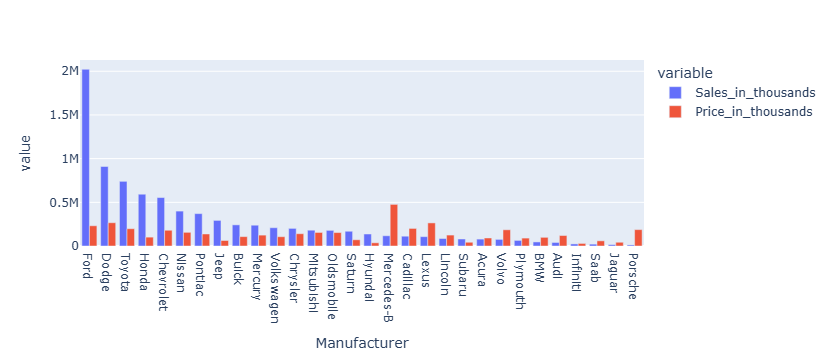

In [41]:
px.bar(bars, barmode='group')

In [56]:
# filter function is to be made and then passed to .filter methord so that it can be used for filtering 
def fltr(x):
    return x['Sales_in_thousands'].sum()>52

In [57]:
df_f=df.groupby('Manufacturer').filter(fltr)

In [58]:
print(df.shape)
print(df_f.shape)

(157, 7)
(144, 7)
